# 5. Stage 5: Data Rejoin

**Stage:** 5.1 of 5 — Daily Unique Rejoin

**Purpose:** Combine all enriched pipeline outputs into one record per vacancy per day. For each daily file, the Stage 1 id/region/click data is first enriched with geographic coordinates via the Stage 4.5 region lookup table, then merged with the Stage 4 ESCO-classified data. The result is a fully enriched daily pickle with all fields ready for monthly aggregation.

**Input:**
- Stage 4 output pickles: `data/stage_04/processed/output/ua-YYYY-MM-DD.pkl`
- Stage 1 id/region/click pickles: `data/stage_01/intermediate/id_region_click/`
- Stage 4.5 region DB: `data/stage_04_5/processed/region_db.pkl`

**Output:** `data/stage_05/intermediate/pkl_daily_unique/ua-YYYY-MM-DD.pkl` + matching `.json` and `_ua.json`

**Run:** Execute all cells top to bottom. No API calls required.

## 5.1. Description

The final stage of the processing pipeline consolidates all intermediate outputs into a single, enriched dataset. This unified format allows for structured analysis, filtering, and visualization of the Ukrainian job market across various dimensions such as skills, occupations, regions, and time.

## 5.2. Load packages and configuration

Enable autoreload, add `code/` to the Python path, and trigger memory cleanup.

In [30]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append("../code")
import general as g
g.clean_memory()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Import `stage1` (for `extract_date_from_file_name`) and `pandas`. The `os` and `pandas` imports are repeated for safety when restarting the kernel mid-session.

In [31]:
import stage1 as st1
import pandas as pd
import os
import pandas as pd

##  Check folders exists

## 5.3. Get or create process log file

Define `get_stage5_process_df()` — loads or creates the Stage 5 unique process tracker. On first run, it scans the Stage 1 id/region/click folder and registers every available daily file. Subsequent runs load the existing tracker and resume from where processing left off.

In [32]:
def get_stage5_process_df(stage5_process_path, stage1_region_path):
    if not os.path.exists(stage5_process_path):
        columns = ["input_path", "region_path", "rejoin_path", "rejoin_status"]
        stage5_process = pd.DataFrame(columns=columns).astype(str)
        file_list = [f for f in os.listdir(stage1_region_path) if f]
        for file in file_list:
            path = os.path.join(stage1_region_path, file)
            new_row = pd.DataFrame([{'input_path': g.get_file_name_without_ext(file), 'region_path': path}])
            stage5_process = pd.concat([stage5_process, new_row], ignore_index=True)
        stage5_process.reset_index(drop=True, inplace=True)
        stage5_process.to_pickle(stage5_process_path)
    else:
        stage5_process = pd.read_pickle(stage5_process_path)

    return stage5_process

Initialise or load the process tracker, sort by filename, and preview. The `rejoin_status` column tracks which files have been processed — `"complete"` rows are skipped in the main loop.

In [33]:
process_df = get_stage5_process_df(g.Config.STAGE5_PROCESS_UNIQUE_PATH, g.Config.STAGE1_ID_REGION_NCLICK_PATH)
process_df = process_df.sort_values(by='input_path').reset_index(drop=True)
process_df

,input_path,region_path,rejoin_path,rejoin_status
0,ua-2024-01-01,../data/stage_01/intermediate/id_region_click\...,NaN,NaN


## 5.4. Rejoin data

### 5.4.1. Rejoin unique daily data

In this folder rejoined data with only daily published job vacancies, without prevoius day published

Ensure all three Stage 5 unique output folders exist: PKL, JSON (all languages), and JSON (Ukrainian-only).

In [34]:
g.check_folder_exists(g.Config.STAGE5_DAILY_UNIQUE_PKL_PATH)
g.check_folder_exists(g.Config.STAGE5_DAILY_UNIQUE_JSON_PATH)
g.check_folder_exists(g.Config.STAGE5_DAILY_UNIQUE_JSON_UA_PATH)

g.check_folder_exists(g.Config.STAGE5_MONTHLY_UNIQUE_PARQUET_PATH)
g.check_folder_exists(g.Config.STAGE5_MONTHLY_UNIQUE_JSON_PATH)
g.check_folder_exists(g.Config.STAGE5_MONTHLY_UNIQUE_JSON_UA_PATH)

Load the Stage 4.5 region lookup table (`region_db.pkl`). This DataFrame maps each raw region string (`original`) to its standardised English oblast name, city, district, country, latitude, and longitude. It is used inside the main loop to enrich every vacancy with geographic coordinates.

In [35]:
region_final_db = pd.read_pickle(g.Config.STAGE4_5_REGION_DB_PATH)
region_final_db

,original,city,district,region,country,latitude,longitude,is_remote
0,Odesa,Odesa,,Odesa Oblast,Ukraine,46.4825,30.7233,false
1,Sumy,Sumy,,Sumy Oblast,Ukraine,50.9077,34.7981,false
2,Khmelnytskyi,Khmelnytskyi,,Khmelnytskyi Oblast,Ukraine,49.4216,26.9965,false
3,Kharkiv,Kharkiv,,Kharkiv Oblast,Ukraine,49.9935,36.2304,false
4,Uzhhorod,Uzhhorod,,Zakarpattia Oblast,Ukraine,48.6208,22.2879,false
...,...,...,...,...,...,...,...,...
25070,"Надітичі, Львовская обл.",Naditychi,,Lviv Oblast,Ukraine,49.6681,23.9306,false
25073,"Успеновка, Бердянский р-н, Запорожская обл.",Uspenovka,Berdyansk District,Zaporizhzhia Oblast,Ukraine,46.8667,36.8667,false
25074,"Поповка, Маньковский р-н, Черкасская обл.",Popivka,Mankivskyi District,Cherkasy Oblast,Ukraine,48.8892,30.3931,false
25075,"Древини, Волынская обл.",Drevyny,,Volyn Oblast,Ukraine,51.5667,25.0667,false


**Main rejoin loop** — processes each daily file in the tracker that has not yet been completed. Three steps per file:

1. **Region enrichment** — merge Stage 1 id/region/click data with `region_final_db` to attach `city`, `district`, `country`, `latitude`, `longitude` and the standardised `region` name
2. **ESCO merge** — join enriched region data with Stage 4 output on `id`
3. **Save** — write result as `.pkl` (full) + `.json` (all languages) + `_ua.json` (Ukrainian descriptions only)

The tracker is updated after each file so the loop can safely be interrupted and resumed.

In [36]:
for _file, _row in process_df.iterrows():
    if _row["rejoin_status"] == "complete" or not os.path.exists(os.path.join(g.Config.STAGE4_OUTPUT_PATH, f"{_row['input_path']}.pkl")):
        print(f"Day: {_row['input_path']} - already rejoined or Stage 4 output missing, skipping")
        continue

    print(f"Day: {_row['input_path']} - rejoining")

    # --- Step 1: load Stage 1 id/region/click data for this day ---
    id_region_df = pd.read_pickle(process_df.loc[_file, 'region_path'])
    id_region_df['id'] = id_region_df['id'].astype('string')

    # --- Step 2: enrich with lat/lon via region_final_db (Stage 4.5 output) ---
    # Merges raw region string → standardised region, city, district, country, latitude, longitude
    pickle_region = pd.merge(id_region_df, region_final_db,
                             how='left', left_on='region', right_on='original')
    pickle_region.drop(columns=['region_x'], inplace=True)
    pickle_region = pickle_region.rename(columns={'original': 'region_original',
                                                  'region_y': 'region'})
    pickle_region['id'] = pickle_region['id'].astype('string')

    # --- Step 3: merge enriched region data with Stage 4 ESCO-classified output ---
    daily_data = pd.read_pickle(
        os.path.join(g.Config.STAGE4_OUTPUT_PATH, f"{process_df.loc[_file, 'input_path']}.pkl")
    )
    daily_data['id'] = daily_data['id'].astype('string')

    daily_data = pd.merge(pickle_region, daily_data, how='left', on='id')

    # --- Step 4: save outputs ---
    pkl_rejoin_path = os.path.join(g.Config.STAGE5_DAILY_UNIQUE_PKL_PATH,
                                   f"{process_df.loc[_file, 'input_path']}.pkl")
    daily_data.to_pickle(pkl_rejoin_path)

    json_rejoin_path = os.path.join(g.Config.STAGE5_DAILY_UNIQUE_JSON_PATH,
                                    f"{process_df.loc[_file, 'input_path']}.json")
    daily_data.to_json(json_rejoin_path, orient='records')

    # Ukrainian-only export (language filter)
    json_ua_rejoin_path = os.path.join(g.Config.STAGE5_DAILY_UNIQUE_JSON_UA_PATH,
                                       f"{process_df.loc[_file, 'input_path']}.json")
    daily_data[daily_data['desc_lang'] == 'uk'].to_json(json_ua_rejoin_path,
                                                         orient='records', force_ascii=False)

    # --- Step 5: update tracker ---
    process_df.loc[_file, 'rejoin_path'] = pkl_rejoin_path
    process_df.loc[_file, 'rejoin_status'] = "complete"
    process_df.to_pickle(g.Config.STAGE5_PROCESS_UNIQUE_PATH)

    print(f"Day: {process_df.loc[_file, 'input_path']} - done "
          f"({daily_data.shape[0]} rows, {daily_data.shape[1]} cols)")

print("All done.")

Day: ua-2024-01-01 - rejoining
Day: ua-2024-01-01 - done (100 rows, 36 cols)
All done.


## 5.5. Inspection and statistics (optional)

The cells below are diagnostic utilities — run them after the main loop to verify output quality. They are not required for the pipeline to proceed to Stage 5.2.

In [37]:
pd.read_pickle("../data/stage_05/intermediate/pkl_daily_unique/ua-2024-01-01.pkl")

,id,number_of_clicks,date,region_original,city,district,region,country,latitude,longitude,...,job_type_score,classified_code,classified_title,skill_labels_en,classified_title_clean,extract_type,esco_title,esco_skills,esco_id,esco_code
0,2673941879650338041,210.0,2024-01-01,Sumy,Sumy,,Sumy Oblast,Ukraine,50.9077,34.7981,...,0.4700,2411,Accountants,"['carry out job analysis', 'motivate employees...",accountants,preferredLabel_fuzzy,accountant,"[""public finance"", ""financial forecasting"", ""b...",http://data.europa.eu/esco/occupation/78db356f...,2411.1.11
1,2829269335131763744,412.0,2024-01-01,Mykolaiv,Mykolaiv,,Mykolaiv Oblast,Ukraine,46.975,31.994,...,0.4894,2411,Accountants,"['consult with technical staff', 'communicate ...",accountants,preferredLabel_fuzzy,accountant,"[""public finance"", ""financial forecasting"", ""b...",http://data.europa.eu/esco/occupation/78db356f...,2411.1.11
2,2292953494970979965,428.0,2024-01-01,Chernihiv,Chernihiv,,Chernihiv Oblast,Ukraine,51.4982,31.2893,...,0.4967,2411,Accountants,['provide training on quality management super...,accountants,preferredLabel_fuzzy,accountant,"[""public finance"", ""financial forecasting"", ""b...",http://data.europa.eu/esco/occupation/78db356f...,2411.1.11
3,8991901255055716088,107.0,2024-01-01,Rivne,Rivne,,Rivne Oblast,Ukraine,50.6199,26.2516,...,0.4720,2132,Software developers,"['cooperate with colleagues', 'manage sales te...",software developers,altLabels,software developer,"[""embedded systems"", ""computer programming"", ""...",http://data.europa.eu/esco/occupation/57af9090...,2514.2.1
4,9937412981206494120,84.0,2024-01-01,Lviv,Lviv,,Lviv Oblast,Ukraine,49.8397,24.0297,...,0.4277,2421,Business analysts,"['innovation processes', 'create software desi...",business analysts,preferredLabel_fuzzy,business analyst,"[""digital data processing"", ""business analysis...",http://data.europa.eu/esco/occupation/60082a99...,2421.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5682536959350677812,191.0,2024-01-01,Odesa,Odesa,,Odesa Oblast,Ukraine,46.4825,30.7233,...,0.4900,1324,Warehouse manager,['interact professionally in research and prof...,warehouse manager,preferredLabel,warehouse manager,"[""warehouse operations"", ""safety regulations f...",http://data.europa.eu/esco/occupation/2f5de1ab...,1324.3.4
96,4745382362973408538,226.0,2024-01-01,Ternopil,Ternopil,,Ternopil Oblast,Ukraine,49.5535,25.5948,...,0.4246,1330,Warehouse manager,"['cooperate with colleagues', 'manage sales te...",warehouse manager,preferredLabel,warehouse manager,"[""warehouse operations"", ""safety regulations f...",http://data.europa.eu/esco/occupation/2f5de1ab...,1324.3.4
97,1748822233724604818,16.0,2024-01-01,Zhytomyr,Zhytomyr,,Zhytomyr Oblast,Ukraine,50.2547,28.6587,...,0.4480,1324,Warehouse manager,['provide training on quality management super...,warehouse manager,preferredLabel,warehouse manager,"[""warehouse operations"", ""safety regulations f...",http://data.europa.eu/esco/occupation/2f5de1ab...,1324.3.4
98,5942472651725435914,426.0,2024-01-01,Dnipro,Dnipro,,Dnipropetrovsk Oblast,Ukraine,48.4647,35.0462,...,0.4383,1324,Warehouse manager,"['consult with technical staff', 'communicate ...",warehouse manager,preferredLabel,warehouse manager,"[""warehouse operations"", ""safety regulations f...",http://data.europa.eu/esco/occupation/2f5de1ab...,1324.3.4


Reload the tracker and preview the first two rows to confirm `rejoin_status` and `rejoin_path` were written correctly.

In [38]:
process_df = pd.read_pickle(g.Config.STAGE5_PROCESS_UNIQUE_PATH)
process_df.head(2)

,input_path,region_path,rejoin_path,rejoin_status
0,ua-2024-01-01,../data/stage_01/intermediate/id_region_click\...,../data/stage_05/intermediate/pkl_daily_unique...,complete


Build a per-file statistics table counting records per language (`en`, `uk`, `ru`, `cs`, `pl`) and how many of those have empty `skill_labels_en`. Useful for spotting extraction gaps across the dataset.

In [39]:
skill_lebels_en_stats = pd.DataFrame({"rejoin_path": process_df["rejoin_path"],
                                      "en": 0, "uk": 0, "ru":0, "cs": 0, "pl":0,
                                      "en_empty": 0, "uk_empty": 0, "ru_empty":0, "cs_empty": 0, "pl_empty":0})
skill_lebels_en_stats.head(2)

,rejoin_path,en,uk,ru,cs,pl,en_empty,uk_empty,ru_empty,cs_empty,pl_empty
0,../data/stage_05/intermediate/pkl_daily_unique...,0,0,0,0,0,0,0,0,0,0


In [40]:
def get_empty_count(dt, lang):
    sm = (data.loc[data["desc_lang"].eq(lang), "skill_labels_en"].apply(len) < 3).sum()
    return sm

for _, row in skill_lebels_en_stats.iterrows():
    print(f"--- {row["rejoin_path"]} ---")

    path = row.get("rejoin_path", None)

    if pd.isna(path):
        continue

    data = pd.read_pickle(row["rejoin_path"])
    skill_lebels_en_stats.loc[_, "en"] = len(data[data["desc_lang"] == "en"])
    skill_lebels_en_stats.loc[_, "uk"] = len(data[data["desc_lang"] == "uk"])
    skill_lebels_en_stats.loc[_, "ru"] = len(data[data["desc_lang"] == "ru"])
    skill_lebels_en_stats.loc[_, "cs"] = len(data[data["desc_lang"] == "cs"])
    skill_lebels_en_stats.loc[_, "pl"] = len(data[data["desc_lang"] == "pl"])

    skill_lebels_en_stats.loc[_, "en_empty"] = get_empty_count(data, "en")
    skill_lebels_en_stats.loc[_, "uk_empty"] = get_empty_count(data, "uk")
    skill_lebels_en_stats.loc[_, "ru_empty"] = get_empty_count(data, "ru")
    skill_lebels_en_stats.loc[_, "cs_empty"] = get_empty_count(data, "cs")
    skill_lebels_en_stats.loc[_, "pl_empty"] = get_empty_count(data, "pl")

skill_lebels_en_stats

--- ../data/stage_05/intermediate/pkl_daily_unique\ua-2024-01-01.pkl ---


,rejoin_path,en,uk,ru,cs,pl,en_empty,uk_empty,ru_empty,cs_empty,pl_empty
0,../data/stage_05/intermediate/pkl_daily_unique...,100,0,0,0,0,0,0,0,0,0


In [12]:
sms = skill_lebels_en_stats.iloc[:, 1:].sum()
sms

en          100
uk            0
ru            0
cs            0
pl            0
en_empty      0
uk_empty      0
ru_empty      0
cs_empty      0
pl_empty      0
dtype: int64

In [ ]:
round(100*sms["en_empty"]/sms["en"],2)

In [ ]:
round(100*sms["pl_empty"]/sms["pl"],2)

In [ ]:
round(100*sms["uk_empty"]/sms["uk"],2)

In [ ]:
round(100*sms["ru_empty"]/sms["ru"],2)

In [ ]:
round(100*sms["cs_empty"]/sms["cs"],2)

## Chesk skill_labesl_en statisics

Aggregate skill coverage statistics by year. For each language and year, counts vacancies with and without English skill labels and plots the distribution as a grouped bar chart.

In [13]:
import pandas as pd
process_df = pd.read_pickle(g.Config.STAGE5_PROCESS_UNIQUE_PATH)

In [14]:
stats_df = pd.DataFrame({"year": range(2022,2026), "en": 0, "uk": 0, "ru":0, "cs": 0, "pl":0, "en_total": 0, "uk_total": 0, "ru_total":0, "cs_total": 0, "pl_total":0})
stats_df

,year,en,uk,ru,cs,pl,en_total,uk_total,ru_total,cs_total,pl_total
0,2022,0,0,0,0,0,0,0,0,0,0
1,2023,0,0,0,0,0,0,0,0,0,0
2,2024,0,0,0,0,0,0,0,0,0,0
3,2025,0,0,0,0,0,0,0,0,0,0


In [15]:
#_ = 0
#row = process_df.iloc[_, :]
langs = ["en", "uk", "ru", "cs", "pl"]
for _, row in process_df.iterrows():
    if not pd.isna(row["rejoin_path"]):
        data = pd.read_pickle(row["rejoin_path"])
        year = pd.to_datetime(data.loc[0, 'date']).year

        for lang in langs:
            stats_df.loc[stats_df["year"] == year, f"{lang}_total"] += data[data["desc_lang"] == lang].shape[0]

        data = data.loc[data["skill_labels_en"].apply(len) < 3]

        for lang in langs:
            stats_df.loc[stats_df["year"] == year, lang] += data[data["desc_lang"] == lang].shape[0]
        print(f"Date: {row["rejoin_path"]} - done")
stats_df

Date: ../data/stage_05/intermediate/pkl_daily_unique\ua-2024-01-01.pkl - done


,year,en,uk,ru,cs,pl,en_total,uk_total,ru_total,cs_total,pl_total
0,2022,0,0,0,0,0,0,0,0,0,0
1,2023,0,0,0,0,0,0,0,0,0,0
2,2024,0,0,0,0,0,100,0,0,0,0
3,2025,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='year'>

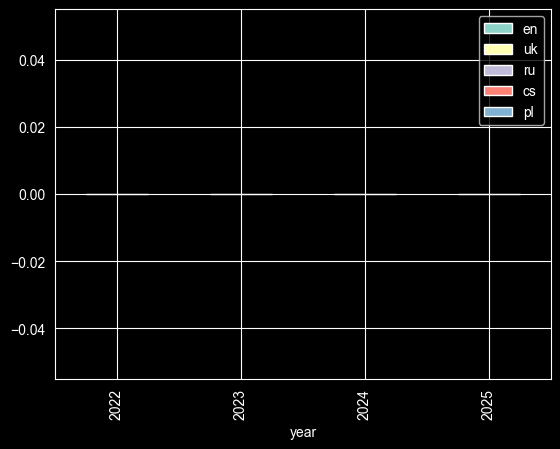

In [16]:
stats_df.plot.bar(x="year", y=["en", "uk", "ru", "cs", "pl"])

In [17]:
stats_df_perc = stats_df.copy()

for y in stats_df_perc["year"]:
    for lang in langs:
        stats_df_perc.loc[stats_df["year"] == y, f"{lang}"] = round(100*stats_df_perc.loc[stats_df_perc["year"] == y, f"{lang}"]/stats_df_perc.loc[stats_df_perc["year"] == y, f"{lang}_total"],2)
stats_df_perc

,year,en,uk,ru,cs,pl,en_total,uk_total,ru_total,cs_total,pl_total
0,2022,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
1,2023,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2,2024,0.0,NaN,NaN,NaN,NaN,100,0,0,0,0
3,2025,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0


---
© 2026 Yurii Kleban, Britta Rude. All rights reserved.